# Strategy Expansion 04 - Component pair trading and cointegration

This notebook turns pair trading into component relationship trading. A pair is interesting when its trend and cycle components are similar enough, while the residual gap creates the temporary tradable deviation.

## Component pair hypothesis

For assets A and B, the decomposition-first pair hypothesis is:

```text
trend_A ≈ beta * trend_B
cycle_A ≈ beta * cycle_B
residual_A - beta * residual_B is the tradable gap
```

The notebook also reports Engle-Granger and ADF diagnostics for cointegration and spread stationarity.

In [1]:
import matplotlib.pyplot as plt

from quant_trading.data import load_bundled_real_ohlcv_panel, ohlcv_panel_to_field
from quant_trading.strategy_component_pairs import (
    ComponentPairConfig,
    collect_pair_orders_and_trades,
    run_component_pair_suite,
)

In [2]:
pairs = [('AUDUSD=X', 'NZDUSD=X'), ('EURUSD=X', 'GBPUSD=X'), ('CADUSD=X', 'CHFUSD=X')]
assets = sorted({x for pair in pairs for x in pair})
panel = load_bundled_real_ohlcv_panel(assets, min_observations=180)
close = ohlcv_panel_to_field(panel, 'Close')
volume = ohlcv_panel_to_field(panel, 'Volume')
execution_prices = ohlcv_panel_to_field(panel, 'Open').shift(-1).reindex_like(close).ffill()
close.tail()

,AUDUSD=X,CADUSD=X,CHFUSD=X,EURUSD=X,GBPUSD=X,NZDUSD=X
Date,,,,,,
2017-12-27,0.773043,0.788208,1.010407,1.185789,1.337471,0.703250
2017-12-28,0.777484,0.790533,1.014405,1.190079,1.340393,0.706969
2017-12-29,0.779429,0.795830,1.021764,1.194172,1.344086,0.709341
2018-01-01,0.780214,0.794862,1.026979,1.200495,1.351607,0.711389
2018-01-02,0.780104,0.796495,1.025936,1.201158,1.351132,0.708818


In [3]:
config = ComponentPairConfig(
    method='STL',
    period=42,
    train_window=126,
    step=126,
    z_window=63,
    require_cointegration=False,
)

stats, results, diagnostics, feature_snapshot = run_component_pair_suite(
    close,
    pairs,
    volumes=volume,
    config=config,
    execution_prices=execution_prices,
)

stats

,strategy,strategy_family,total_return,cagr,sharpe,max_drawdown,calmar,volatility,hit_rate,trade_win_rate,...,config_entry_z,config_exit_z,config_min_trend_corr,config_min_cycle_corr,config_max_fair_spread_trend_abs,config_max_cointegration_pvalue,config_require_cointegration,config_allow_short,config_max_gross,config_name
2,detime_STL_p42_tw126_fair_spread_deviation,fair_spread_deviation,-0.026813,-0.006545,-0.145962,-0.107916,-0.060650,0.039615,0.360499,0.581633,...,1.5,0.25,0.5,0.25,0.0025,0.1,False,True,1.0,STL_p42_tw126
0,classic_pair_spread_zscore,classic_pair_spread_zscore,-0.090993,-0.022787,-0.578682,-0.136457,-0.166987,0.038546,0.477469,0.568966,...,1.5,0.25,0.5,0.25,0.0025,0.1,False,True,1.0,STL_p42_tw126
1,detime_STL_p42_tw126_component_residual_gap,component_residual_gap,-0.066820,-0.016570,-0.694842,-0.095011,-0.174405,0.023643,0.141898,0.400000,...,1.5,0.25,0.5,0.25,0.0025,0.1,False,True,1.0,STL_p42_tw126
3,detime_STL_p42_tw126_cointegration_filtered_re...,cointegration_filtered_residual_gap,-0.071954,-0.017880,-0.714658,-0.091280,-0.195884,0.024813,0.133269,0.437500,...,1.5,0.25,0.5,0.25,0.0025,0.1,False,True,1.0,STL_p42_tw126


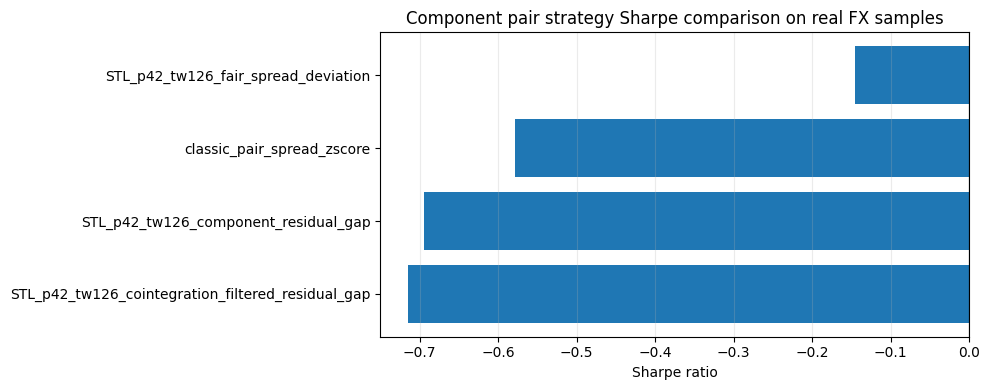

In [4]:
plot_stats = stats.sort_values("sharpe", ascending=True).copy()
labels = plot_stats["strategy"].astype(str).str.replace("detime_", "", regex=False)
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(labels, plot_stats["sharpe"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Sharpe ratio")
ax.set_title("Component pair strategy Sharpe comparison on real FX samples")
ax.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Read the diagnostics

- `latest_trend_corr` measures whether the two decomposed trends are currently similar.
- `latest_cycle_corr` measures whether their cycles are currently aligned.
- `raw_price_coint_pvalue` is the Engle-Granger test p-value on log prices.
- `fair_value_coint_pvalue` applies the same idea to trend + cycle fair values.
- `raw_spread_adf_pvalue`, `fair_spread_adf_pvalue`, and `residual_gap_adf_pvalue` test whether the relevant spread is stationary enough for a mean-reversion hypothesis.

In [5]:
diagnostics

,pair,method_variant,date,latest_beta,latest_return_corr,latest_trend_corr,latest_cycle_corr,latest_residual_corr,latest_raw_spread,latest_fair_spread,...,fair_spread_adf_valid,fair_spread_adf_reason,residual_gap_adf_test,residual_gap_adf_statistic,residual_gap_adf_pvalue,residual_gap_adf_critical_1pct,residual_gap_adf_critical_5pct,residual_gap_adf_critical_10pct,residual_gap_adf_valid,residual_gap_adf_reason
0,AUDUSD=X/NZDUSD=X,STL_p42_tw126,2018-01-02,0.509809,0.632244,1.0,1.0,1.0,-0.072874,-0.080892,...,True,,adf,-1.669352,0.446969,-3.436641,-2.864318,-2.568249,True,
1,EURUSD=X/GBPUSD=X,STL_p42_tw126,2018-01-02,0.406596,0.446730,1.0,1.0,1.0,0.060924,0.041900,...,True,,adf,-1.808907,0.376049,-3.436641,-2.864318,-2.568249,True,
2,CADUSD=X/CHFUSD=X,STL_p42_tw126,2018-01-02,0.422316,0.403466,-1.0,1.0,1.0,-0.238348,-0.235834,...,True,,adf,-1.247762,0.652720,-3.436641,-2.864318,-2.568249,True,


In [6]:
orders, trades = collect_pair_orders_and_trades(results)
print('orders:', len(orders))
print('round-trip trades:', len(trades))
trades.head()

orders: 8850
round-trip trades: 192


,strategy,asset,side,entry_signal_date,entry_fill_date,exit_signal_date,exit_fill_date,entry_price,exit_price,bars_held,entry_weight,directional_return,approx_weighted_return_after_cost
0,classic_pair_spread_zscore,AUDUSD=X,long,2014-03-13,2014-03-14,2014-08-28,2014-08-29,0.903016,0.935016,120,0.166667,0.035437,0.005789
1,classic_pair_spread_zscore,AUDUSD=X,long,2014-09-10,2014-09-11,2015-04-29,2015-04-30,0.915667,0.799488,165,0.316258,-0.126879,-0.040348
2,classic_pair_spread_zscore,AUDUSD=X,short,2015-05-14,2015-05-15,2015-07-28,2015-07-29,0.808473,0.734808,53,-0.296715,0.091116,0.026828
3,classic_pair_spread_zscore,AUDUSD=X,long,2015-09-04,2015-09-07,2015-12-03,2015-12-04,0.693577,0.733192,64,0.205421,0.057117,0.011589
4,classic_pair_spread_zscore,AUDUSD=X,short,2016-02-09,2016-02-10,2016-05-19,2016-05-20,0.706614,0.723223,72,-0.194131,-0.023505,-0.004699


## Strategy variants

The suite compares a classical raw spread z-score baseline with three decomposition-first variants:

- `component_residual_gap`: trades residual_z differences when trend and cycle are similar;
- `fair_spread_deviation`: trades price spread deviation from the decomposed trend+cycle relationship;
- `cointegration_filtered_residual_gap`: requires cointegration/stationarity diagnostics before trading residual gaps.